In [1]:
pip install altair==5.3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.8/857.8 kB 8.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: altair
    Found existing installation: altair 5.1.1
    Uninstalling altair-5.1.1:
      Successfully uninstalled altair-5.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.26.0 requires importlib-metadata<7,>=1.4, but you have importlib-metadata 7.0.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
#from sklearn import metrics 
from xailib.data_loaders.dataframe_loader import prepare_dataframe


from lore_sa.dataset import TabularDataset

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
import altair as alt
alt.data_transformers.enable('default', max_rows=None)
import seaborn as sns

In [4]:
df = pd.read_csv("../../datasets/Covid_categorical_feature_data_1.csv")
 
df = df.loc[:,['Class_label', 'Week6_Covid','Week5_Covid','Week4_Covid','Week3_Covid','Week2_Covid' ,'Week1_Covid','Week6_Mobility','Week5_Mobility','Week4_Mobility','Week3_Mobility','Week2_Mobility','Week1_Mobility']]
 
mask = df.drop("Class_label", axis=1).isna().all(axis=1) & df['Class_label'].notna()
result_df = df[~mask]
 
result_df = result_df.fillna("NONE")

In [5]:
result_df.to_csv('../../datasets/neighbourhood.csv', index=False)  
dataset=TabularDataset.from_csv('../../datasets/neighbourhood.csv', class_name="Class_label")

2024-05-07 09:11:41,378 root         INFO     ../../datasets/neighbourhood.csv file imported


In [6]:
dataset.df

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,Class_label
0,AND,AND,NONE,NONE,NONE,NONE,NM,NM,NONE,NONE,NONE,NONE,almost no disease
1,AND,AND,AND,AND,AND,AND,NM,NM,NM,NM,NM,NM,low to medium morbidity
2,LMM,LMM,LMM,LMM,LMM,LMM,DM,SH,SH,SH,SH,SH,almost no disease
3,NONE,NONE,NONE,AND,AND,AND,NONE,NONE,NONE,NM,NM,NM,low to medium morbidity
4,AND,AND,AND,AND,AND,AND,NM,NM,NM,NM,NM,NM,low to medium morbidity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,NONE,NONE,AND,AND,AND,AND,NONE,NONE,NM,NM,NM,NM,low to medium morbidity
395,HM,HM,HM,HM,HM,HM,NM,NM,NM,NM,NM,NM,low to medium morbidity
396,LMM,LMM,LMM,LMM,LMM,LMM,NM,NM,NM,NM,NM,NM,high morbidity
397,HMM,HMM,HMM,HMM,HMM,HMM,NM,NM,NM,NM,NM,NM,high morbidity


### ORDINAL ENCODER

In [7]:
from sklearn.preprocessing import OrdinalEncoder
y = dataset.df["Class_label"]
X = dataset.df.loc[:,'Week6_Covid':'Week1_Mobility']
 
covid_categories = ['NONE', 'AND', 'LMM', 'HM', 'HMM']
mobility_categories = ['NONE', 'NM', 'DM', 'SH', 'IM']

In [8]:
enc = OrdinalEncoder(categories=[covid_categories for i in range(6)] + [mobility_categories for i in range(6)])
 
X = enc.fit_transform(X)
 
df = pd.concat([y.reset_index(drop=True),pd.DataFrame(X)],  axis = 1)
df.columns = [dataset.df.columns[-1],*dataset.df.columns[:-1]]

In [9]:
[dataset.df.columns[-1],*dataset.df.columns[:-1]]

['Class_label',
 'Week6_Covid',
 'Week5_Covid',
 'Week4_Covid',
 'Week3_Covid',
 'Week2_Covid',
 'Week1_Covid',
 'Week6_Mobility',
 'Week5_Mobility',
 'Week4_Mobility',
 'Week3_Mobility',
 'Week2_Mobility',
 'Week1_Mobility']

In [10]:
dataset.df.columns

Index(['Week6_Covid', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid',
       'Week2_Covid', 'Week1_Covid', 'Week6_Mobility', 'Week5_Mobility',
       'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Week1_Mobility',
       'Class_label'],
      dtype='object')

In [11]:
df.head()

,Class_label,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,almost no disease,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,low to medium morbidity,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,almost no disease,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0
3,low to medium morbidity,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
4,low to medium morbidity,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [12]:
enc_dataset = TabularDataset(df, class_name="Class_label")

In [13]:
enc_dataset.df

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,Class_label
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,almost no disease
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,low to medium morbidity
2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,almost no disease
3,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,low to medium morbidity
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,low to medium morbidity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,low to medium morbidity
395,3.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,low to medium morbidity
396,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,high morbidity
397,4.0,4.0,4.0,4.0,4.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,high morbidity


### THE BBOX

In [14]:
from sklearn.metrics import f1_score, accuracy_score
from imblearn.over_sampling import RandomOverSampler
feature_names = [c for c in enc_dataset.df.columns if c != 'Class_label']
class_name = dataset.class_name
test_size= 0.2
random_state= 42
ros = RandomOverSampler(random_state = 0)
X, y = ros.fit_resample(enc_dataset.df[feature_names].values,enc_dataset.df[class_name].values)
X_train, X_test, Y_train, Y_test = train_test_split(X, y,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    #stratify=encoded_df[class_name].values
                                                   )




# Train a random forest model

bb = RandomForestClassifier(n_estimators=100, random_state=random_state)

# bb = MLPClassifier(random_state=random_state)
bb.fit(X_train, Y_train)

Y_pred = bb.predict(X_test)
target_names = bb.classes_


print('Accuracy %.3f' % accuracy_score(Y_test, Y_pred))

# example of predictions
Y_pred = bb.predict(X_test)

from lore_sa.bbox import sklearn_classifier_bbox

bbox = sklearn_classifier_bbox.sklearnBBox(bb)

Accuracy 0.847


In [17]:
predictions = bb.predict(X_test)
cm = confusion_matrix(Y_test, predictions, labels=bb.classes_)

2024-05-07 09:12:12,474 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7f986def2cd0>


<Axes: >

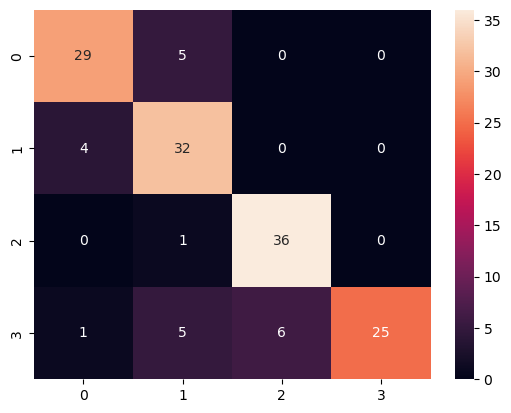

In [18]:
sns.heatmap(cm, annot=True)

### GENERATOR

In [19]:
import random
class NewGen:
    def __init__(self):
        self.gen_data = None
 
    def perturb(self, x, num_instances):
        perturbed_arrays = []
        for _ in range(num_instances):
            perturbed_arr = x[:]
 
            # Initial probabilities based on the initial data
            probabilities_covid = [0.0, 0.26, 0.11, 0.36, 0.27]
            probabilities_mobility = [0.0, 0.68, 0.10, 0.17, 0.05]
            choices = [0, 1, 2, 3, 4]
 
 
            for val in range(0, int(len(x)/2)):
               
                if val == 0:
                    perturbed_arr[val] = random.choices(choices, weights = probabilities_covid)[0]
                    perturbed_arr[val+6] = random.choices(choices, weights = probabilities_mobility)[0]
                else:
                    probabilities_covid = [0.0, 0.4, 0.3, 0.2, 0.1] if perturbed_arr[val-1]==1 else [0.0, 0.25, 0.4, 0.25, 0.1] if perturbed_arr[val-1]==2 else [0.0, 0.1, 0.25, 0.4, 0.25] if perturbed_arr[val-1]==3 else [0.0, 0.1, 0.2, 0.3, 0.4]
                    perturbed_arr[val] = random.choices(choices, weights = probabilities_covid)[0]
                    probabilities_mobility = [0.0, 0.4, 0.3, 0.2, 0.1] if perturbed_arr[val-1+6]==1 else [0.0, 0.25, 0.4, 0.25, 0.1] if perturbed_arr[val-1+6]==2 else [0.0, 0.1, 0.25, 0.4, 0.25] if perturbed_arr[val-1+6]==3 else [0.0, 0.1, 0.2, 0.3, 0.4]
                    perturbed_arr[val+6] = random.choices(choices, weights = probabilities_mobility)[0]
 
 
            perturbed_arrays.append(perturbed_arr)
        self.gen_data = perturbed_arrays
        return perturbed_arrays
 
 
# Example usage:
 
 
x =list(X_train[44])
perturber = NewGen()
n = 100
perturbed_arrays = perturber.perturb(x=x, num_instances=n)
for perturbed_arr in perturbed_arrays:
    print(perturbed_arr)

[1, 1, 1, 3, 1, 1, 1, 2, 3, 3, 4, 2]
[3, 1, 3, 3, 1, 2, 1, 1, 2, 3, 2, 1]
[4, 1, 1, 3, 2, 3, 1, 3, 4, 4, 4, 2]
[4, 3, 3, 3, 3, 3, 2, 2, 4, 4, 2, 2]
[4, 3, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1]
[4, 3, 4, 2, 2, 1, 1, 2, 3, 4, 3, 3]
[1, 1, 2, 1, 1, 2, 1, 3, 3, 3, 3, 3]
[3, 1, 1, 2, 1, 4, 1, 1, 2, 1, 2, 3]
[3, 2, 2, 2, 1, 3, 3, 3, 3, 4, 2, 3]
[2, 1, 1, 3, 3, 1, 1, 3, 4, 4, 4, 3]
[3, 3, 3, 3, 3, 3, 2, 1, 2, 1, 1, 2]
[2, 3, 3, 3, 4, 4, 1, 2, 2, 4, 3, 3]
[1, 2, 2, 3, 2, 3, 4, 3, 3, 4, 4, 3]
[3, 3, 2, 4, 4, 4, 1, 1, 2, 2, 3, 1]
[1, 2, 2, 2, 1, 3, 3, 3, 2, 2, 2, 3]
[1, 4, 2, 3, 3, 4, 1, 3, 2, 3, 3, 4]
[1, 1, 1, 1, 2, 1, 1, 2, 4, 3, 3, 3]
[1, 2, 2, 2, 2, 4, 1, 4, 4, 3, 4, 4]
[1, 1, 2, 1, 3, 4, 1, 4, 3, 2, 3, 2]
[1, 3, 4, 3, 1, 1, 1, 1, 1, 2, 1, 1]
[4, 3, 3, 4, 4, 3, 2, 2, 1, 3, 2, 4]
[3, 2, 3, 3, 3, 2, 1, 1, 1, 2, 1, 3]
[3, 2, 2, 4, 4, 1, 1, 1, 3, 1, 2, 1]
[4, 4, 3, 1, 1, 2, 3, 4, 4, 4, 1, 1]
[3, 3, 4, 1, 1, 1, 2, 2, 2, 2, 2, 1]
[3, 3, 4, 3, 3, 3, 1, 2, 3, 4, 3, 2]
[1, 2, 1, 1, 1, 2, 3, 3, 2, 2, 3, 2]
[

In [20]:
enc_dataset.df[feature_names].columns

Index(['Week6_Covid', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid',
       'Week2_Covid', 'Week1_Covid', 'Week6_Mobility', 'Week5_Mobility',
       'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Week1_Mobility'],
      dtype='object')

In [21]:
columns=enc_dataset.df[feature_names].columns

In [22]:
neighbour_df = pd.DataFrame(perturbed_arrays, columns=columns)

### Create a DF for the Neighbourhood

In [23]:
#Exporting the neigh_df into a csv to transform it into an object that will be used to generate the rule,
#it is the quickest thing to do but not the smartest
neighbour_df.to_csv('../../datasets/neighbourhood.csv', index=False)  
neighbour=TabularDataset.from_csv('../../datasets/neighbourhood.csv')

2024-05-07 09:12:40,701 root         WARNING  No target class is defined
2024-05-07 09:12:40,702 root         INFO     ../../datasets/neighbourhood.csv file imported


In [24]:
neighbour.df['Class_label'] = bbox.predict(neighbour.df)
neighbour.set_class_name('Class_label')

/opt/anaconda3/envs/xai/lib/python3.8/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [25]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
neighbour.df['Class_label'] = le.fit_transform(neighbour.df['Class_label']) 
neighbour.df['Class_label']

0     3
1     1
2     2
3     2
4     3
     ..
95    1
96    2
97    3
98    1
99    3
Name: Class_label, Length: 100, dtype: int64

### Create the Surrogate

In [26]:
features = [c for c in neighbour.df.columns if c != neighbour.class_name]

In [27]:
from lore_sa.surrogate import DecisionTreeSurrogate
surrogate = DecisionTreeSurrogate()
surrogate.train(neighbour.df[features].values , neighbour.df['Class_label'] )

DecisionTreeClassifier()

In [28]:
neighbour.df

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,Class_label
0,1,1,1,3,1,1,1,2,3,3,4,2,3
1,3,1,3,3,1,2,1,1,2,3,2,1,1
2,4,1,1,3,2,3,1,3,4,4,4,2,2
3,4,3,3,3,3,3,2,2,4,4,2,2,2
4,4,3,2,2,1,1,1,2,1,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4,2,2,2,3,4,1,1,3,3,4,3,1
96,4,4,3,4,2,3,1,1,1,1,2,3,2
97,2,4,3,3,3,2,4,3,2,1,1,1,3
98,1,1,1,1,4,4,1,2,4,4,4,4,1


In [32]:
decoded_array = enc.inverse_transform(neighbour.df[features])

In [37]:
from lore_sa.encoder_decoder import EncDec
class IdentityEncoder(EncDec):
    """
    It provides an interface to access Identity encoding functions.
    """
    def __init__(self,dataset_descriptor):
        super().__init__(dataset_descriptor)

    def encode(self, x: np.array) -> np.array:
        """
        It applies the encoder to the input features

        :param [Numpy array] x: Array to encode
        :return [Numpy array]: Encoded array
        """
        return x

    def get_encoded_features(self):
        """
        Provides a dictionary with the new encoded features name and the new index
        :return:
        """
        return self.encoded_features

    def decode(self, x: np.array) -> np.array:
        return x

    def decode_target_class(self, x: np.array):
        return x

In [34]:
decoded_df = pd.DataFrame(decoded_array, columns=features)
decoded_df

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,AND,AND,AND,HM,AND,AND,NM,DM,SH,SH,IM,DM
1,HM,AND,HM,HM,AND,LMM,NM,NM,DM,SH,DM,NM
2,HMM,AND,AND,HM,LMM,HM,NM,SH,IM,IM,IM,DM
3,HMM,HM,HM,HM,HM,HM,DM,DM,IM,IM,DM,DM
4,HMM,HM,LMM,LMM,AND,AND,NM,DM,NM,NM,NM,NM
...,...,...,...,...,...,...,...,...,...,...,...,...
95,HMM,LMM,LMM,LMM,HM,HMM,NM,NM,SH,SH,IM,SH
96,HMM,HMM,HM,HMM,LMM,HM,NM,NM,NM,NM,DM,SH
97,LMM,HMM,HM,HM,HM,LMM,IM,SH,DM,NM,NM,NM
98,AND,AND,AND,AND,HMM,HMM,NM,DM,IM,IM,IM,IM


### RULES

In [39]:
x = decoded_n[2]
x1=neighbour.df[features].iloc[22].values
rule = surrogate.get_rule(x1, neighbour, IdentityEncoder(enc_dataset.descriptor))

print(rule)

premises:
Week1_Covid <= 1.5
Week6_Covid <= 3.5 
consequence: Class_label = [3]


In [41]:
x = decoded_n[2]
x1=neighbour.df[features].iloc[22].values
rule = surrogate.get_rule(x1, neighbour, IdentityEncoder(enc_dataset.descriptor))
print(rule)

premises:
Week1_Covid <= 1.5
Week6_Covid <= 3.5 
consequence: Class_label = [3]


## HEATMAP

2024-04-26 11:15:18,489 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7f94b580cb80>


<Axes: >

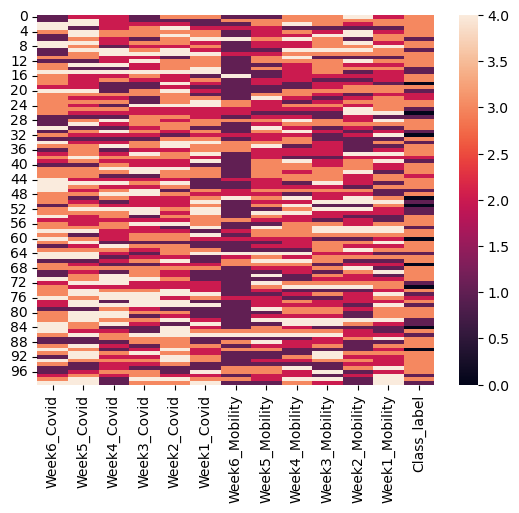

In [41]:
sns.heatmap(neighbour.df)

### ALTAIR heatmap

In [44]:
#need to change the structure of the df
decoded_df['id'] = decoded_df.index  # Create a new column to preserve the row index

# Melt the DataFrame
alt_df = pd.melt(decoded_df, id_vars=['id'], var_name='Week_Metric', value_name='Value')

alt_df.tail(20)

,id,Week_Metric,Value
1180,80,Week1_Mobility,IM
1181,81,Week1_Mobility,NM
1182,82,Week1_Mobility,SH
1183,83,Week1_Mobility,DM
1184,84,Week1_Mobility,DM
1185,85,Week1_Mobility,IM
1186,86,Week1_Mobility,DM
1187,87,Week1_Mobility,SH
1188,88,Week1_Mobility,SH
1189,89,Week1_Mobility,DM


In [95]:
domain_ = ['AND', 'LMM', 'HM', 'HMM','NM','DM','SH','IM']
range_= ['#264653', '#2a9d8f', '#e9c46a', '#f4a261','#264653','#2a9d8f','#e76f51','#c9f0eb'] #evitare conflitti con funzione predefinita

week_order = [
    'Week6_Covid', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week2_Covid', 'Week1_Covid',
    'Week6_Mobility', 'Week5_Mobility', 'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Week1_Mobility'
]


alt.Chart(alt_df).mark_rect().encode(
    x=alt.X('Week_Metric:N', sort=week_order, axis=alt.Axis(labelAngle=0, title=None, ticks=False, grid=False, orient='top')),
    y=alt.Y('id:O',axis=alt.Axis(ticks=False, title=None, grid=False, labels=False) ),
    color=alt.Color('Value', scale=alt.Scale(domain=domain_, range=range_)),
    tooltip=['Week_Metric', 'Value']
).properties(
    title="COVID and Mobility Data Over Six Weeks",
    width=900,
    height=900
)

alt.Chart(...)

### TRAINING SET MATRIX

In [69]:
#drop all columns that have none values
df_clean = dataset.df[~dataset.df.isin(['NONE']).any(axis=1)]
df_clean = df_clean.drop('Class_label', axis=1)
df_clean 

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
1,AND,AND,AND,AND,AND,AND,NM,NM,NM,NM,NM,NM
2,LMM,LMM,LMM,LMM,LMM,LMM,DM,SH,SH,SH,SH,SH
4,AND,AND,AND,AND,AND,AND,NM,NM,NM,NM,NM,NM
5,HM,HM,HM,HM,HM,HM,DM,IM,NM,NM,NM,NM
6,LMM,LMM,LMM,LMM,LMM,LMM,NM,NM,NM,NM,NM,NM
...,...,...,...,...,...,...,...,...,...,...,...,...
393,HM,HM,HM,HM,HM,HM,NM,NM,NM,NM,NM,NM
395,HM,HM,HM,HM,HM,HM,NM,NM,NM,NM,NM,NM
396,LMM,LMM,LMM,LMM,LMM,LMM,NM,NM,NM,NM,NM,NM
397,HMM,HMM,HMM,HMM,HMM,HMM,NM,NM,NM,NM,NM,NM


In [71]:
df_clean
#need to change the structure of the df
df_clean['id'] = df_clean.index  # Create a new column to preserve the row index

# Melt the DataFrame
alt_df_or = pd.melt(df_clean, id_vars=['id'], var_name='Week_Metric', value_name='Value')

alt_df_or.tail(20)

,id,Week_Metric,Value
4120,377,Week1_Mobility,NM
4121,378,Week1_Mobility,NM
4122,379,Week1_Mobility,NM
4123,380,Week1_Mobility,SH
4124,381,Week1_Mobility,DM
4125,383,Week1_Mobility,SH
4126,384,Week1_Mobility,IM
4127,385,Week1_Mobility,NM
4128,386,Week1_Mobility,SH
4129,387,Week1_Mobility,IM


In [76]:
domain_ = ['AND', 'LMM', 'HM', 'HMM','NM','DM','SH','IM']
range_= ['#264653', '#2a9d8f', '#e9c46a', '#f4a261','#264653','#2a9d8f','#e76f51','#c9f0eb'] #evitare conflitti con funzione predefinita

week_order = [
    'Week6_Covid', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week2_Covid', 'Week1_Covid',
    'Week6_Mobility', 'Week5_Mobility', 'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Week1_Mobility'
]


alt.Chart(alt_df_or).mark_rect().encode(
    x=alt.X('Week_Metric:N', axis=alt.Axis(labelAngle=0, title=None, ticks=False, grid=False, orient='top'), sort=week_order),
    y=alt.Y('id:O',axis=alt.Axis(ticks=False, title=None, grid=False, labels=False) ),
    color=alt.Color('Value', scale=alt.Scale(domain=domain_, range=range_)),
    tooltip=['Week_Metric', 'Value']
).properties(
    title="COVID and Mobility Data Over Six Weeks",
    width=900,
    height=600
)

alt.Chart(...)

2024-04-26 12:08:27,973 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7f94a78daeb0>


<Axes: >

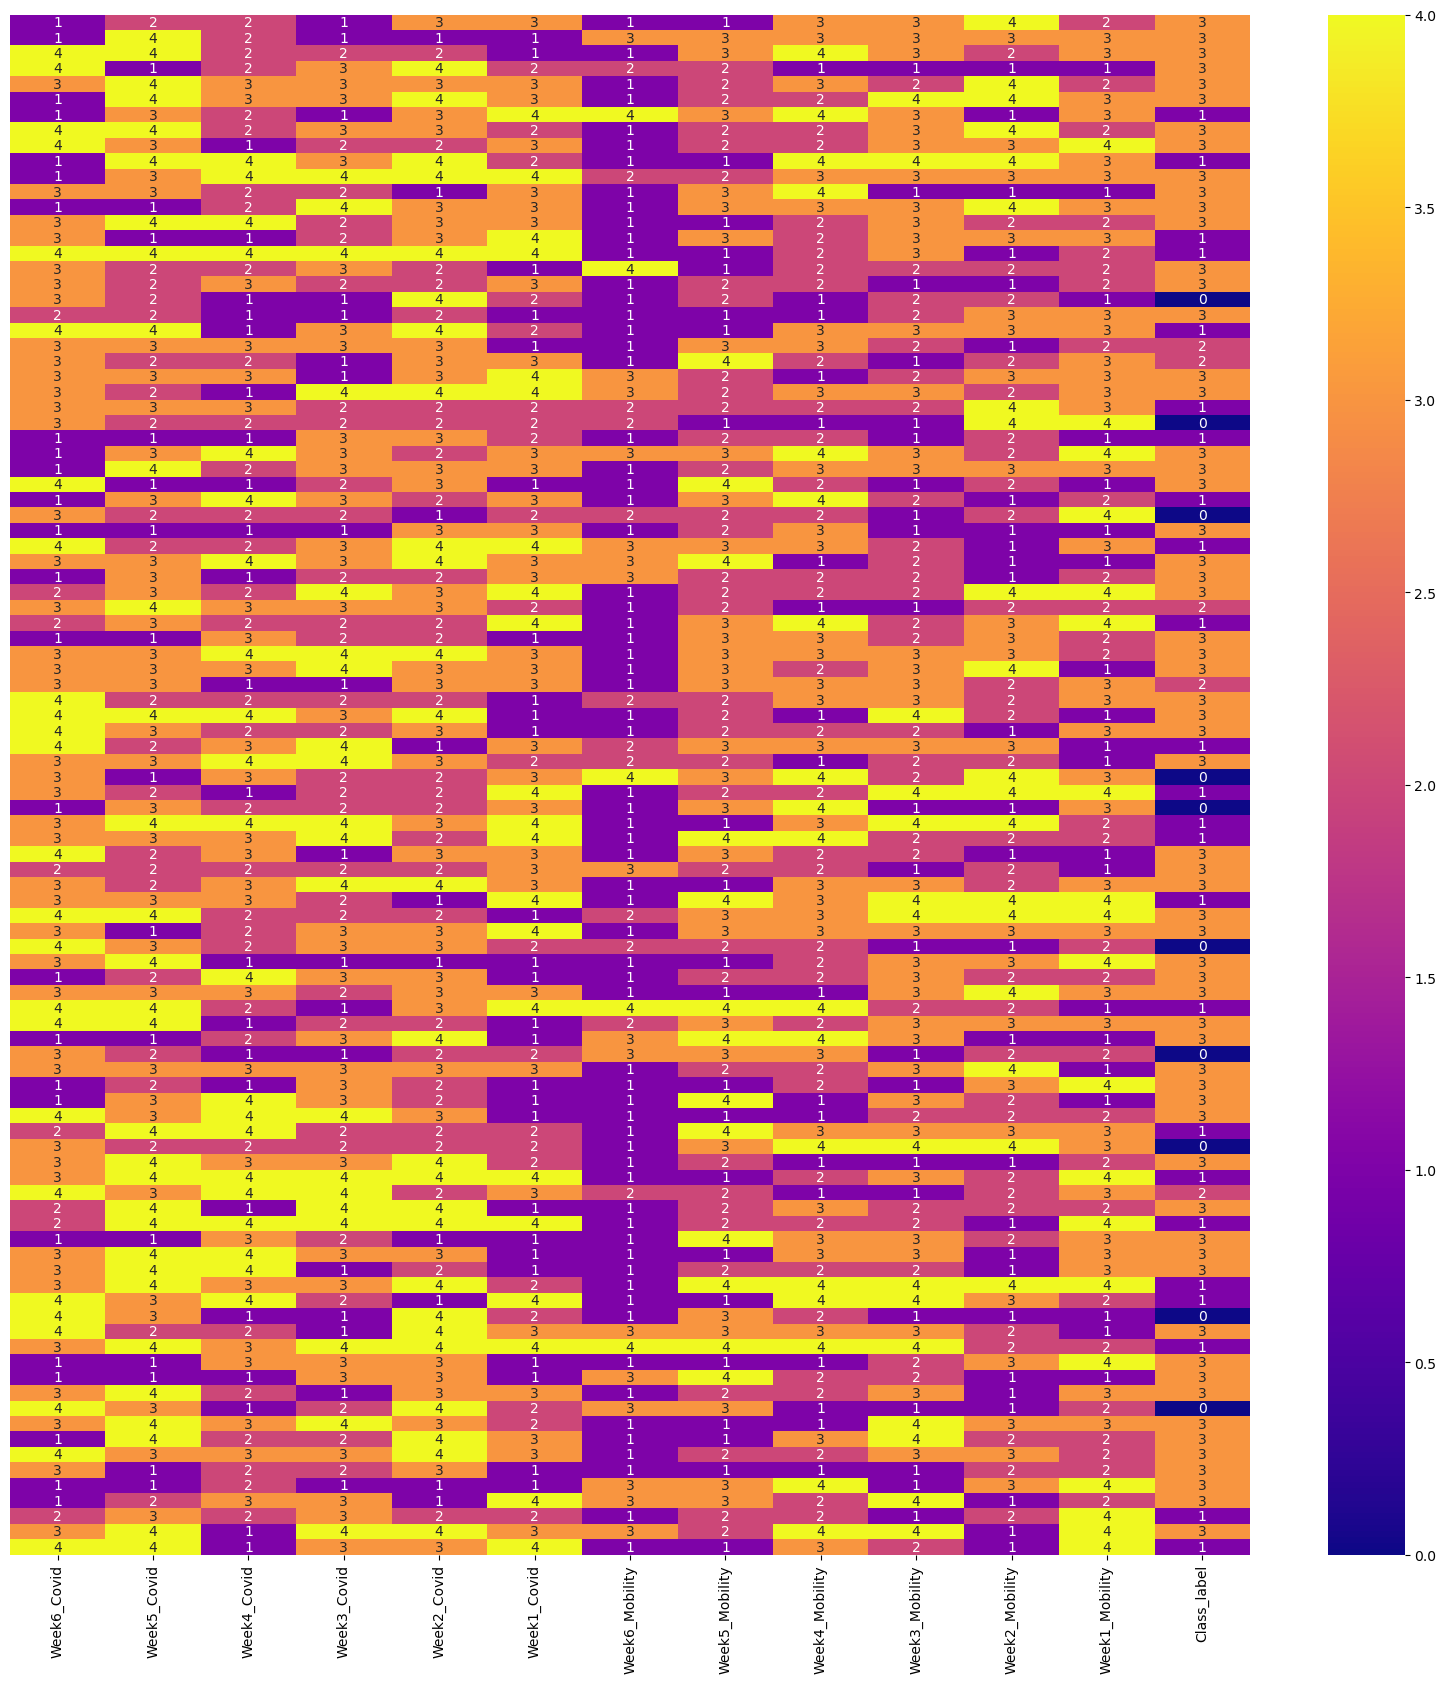

In [76]:
plt.figure(figsize=(20,20))
sns.heatmap(neighbour.df, cmap='plasma', yticklabels=False, annot=True)

### TRY TO DECODE DATA FROM THE ORDINAL ENCODER

In [54]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomOrdinalEncoder(BaseEstimator, TransformerMixin):
    """
    This class extends the functionality of sklearn's OrdinalEncoder to provide encoding and decoding capabilities
    within a custom interface.
    """
    def __init__(self, categories='auto', dtype=np.float64):
        """
        Initializes the CustomOrdinalEncoder with optional category and dtype settings.

        :param categories: Specifies category of each feature, 'auto' to determine categories automatically.
        :param dtype: Desired dtype of output.
        """
        self.encoder = OrdinalEncoder(categories=categories, dtype=dtype)

    def fit(self, X, y=None):
        """
        Fit the OrdinalEncoder to X.

        :param X: Array-like of shape (n_samples, n_features) to fit the encoder.
        :param y: Ignored. Exists for compatibility.
        :return: self
        """
        self.encoder.fit(X)
        return self

    def transform(self, X):
        """
        Transforms the provided X using the fitted OrdinalEncoder.

        :param X: Array-like of shape (n_samples, n_features) to encode.
        :return: np.array - Encoded array
        """
        return self.encoder.transform(X)

    def inverse_transform(self, X):
        """
        Decodes the previously encoded X back to original values using the fitted OrdinalEncoder.

        :param X: Array-like of shape (n_samples, n_features) to decode.
        :return: np.array - Decoded array
        """
        return self.encoder.inverse_transform(X)

    def fit_transform(self, X, y=None):
        """
        Fit to data, then transform it.

        :param X: Array-like of shape (n_samples, n_features) to fit then transform.
        :param y: Ignored. Exists for compatibility.
        :return: np.array - Encoded array
        """
        return self.encoder.fit_transform(X)

# Usage example:
data = dataset.df

encoder = CustomOrdinalEncoder()
encoded_data = encoder.fit_transform(data)
print("Encoded Data:")
print(encoded_data)

decoded_data = encoder.inverse_transform(neighbour.df)
print("Decoded Data:")
print(decoded_data)

Encoded Data:
[[0. 0. 4. ... 3. 3. 0.]
 [0. 0. 0. ... 2. 2. 3.]
 [3. 3. 3. ... 4. 4. 0.]
 ...
 [3. 3. 3. ... 2. 2. 1.]
 [2. 2. 2. ... 2. 2. 1.]
 [1. 1. 1. ... 2. 2. 2.]]
Decoded Data:
[['HM' 'HMM' 'HMM' ... 'SH' 'NM' 'low to medium morbidity']
 ['HM' 'NONE' 'HMM' ... 'NONE' 'NONE' 'low to medium morbidity']
 ['NONE' 'NONE' 'HMM' ... 'NM' 'NONE' 'low to medium morbidity']
 ...
 ['HMM' 'LMM' 'HMM' ... 'NM' 'SH' 'high morbidity']
 ['LMM' 'NONE' 'HM' ... 'IM' 'SH' 'low to medium morbidity']
 ['NONE' 'NONE' 'HM' ... 'IM' 'SH' 'high morbidity']]


Index(['Week6_Covid', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid',
       'Week2_Covid', 'Week1_Covid', 'Week6_Mobility', 'Week5_Mobility',
       'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Week1_Mobility',
       'Class_label'],
      dtype='object')

In [66]:
en_df = pd.DataFrame(decoded_data)
en_df.columns = dataset.df.columns[:]

In [67]:
en_df

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,Class_label
0,HM,HMM,HMM,HM,LMM,LMM,IM,IM,NONE,NONE,SH,NM,low to medium morbidity
1,HM,NONE,HMM,HM,HM,HM,NONE,NONE,NONE,NONE,NONE,NONE,low to medium morbidity
2,NONE,NONE,HMM,HMM,HMM,HM,IM,NONE,SH,NONE,NM,NONE,low to medium morbidity
3,NONE,HM,HMM,LMM,NONE,HMM,NM,NM,IM,IM,IM,IM,low to medium morbidity
4,LMM,NONE,LMM,LMM,LMM,LMM,IM,NM,NONE,NM,SH,NM,low to medium morbidity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,HM,HM,HMM,HM,HM,HM,NONE,NONE,SH,IM,NONE,SH,low to medium morbidity
96,HM,HMM,LMM,LMM,HM,NONE,NONE,NONE,NM,SH,IM,NM,low to medium morbidity
97,HMM,LMM,HMM,LMM,HMM,HMM,IM,NM,NM,IM,NM,SH,high morbidity
98,LMM,NONE,HM,NONE,NONE,LMM,NONE,NM,SH,SH,IM,SH,low to medium morbidity


In [78]:
enc_nei_dataset = TabularDataset(en_df, class_name="Class_label")

In [80]:
enc_nei_dataset.descriptor

{'numeric': {},
 'categorical': {'Week6_Covid': {'index': 0,
   'distinct_values': ['HM', 'NONE', 'LMM', 'HMM'],
   'count': {'HM': 25, 'NONE': 25, 'LMM': 42, 'HMM': 8}},
  'Week5_Covid': {'index': 1,
   'distinct_values': ['HMM', 'NONE', 'HM', 'LMM'],
   'count': {'HMM': 22, 'NONE': 31, 'HM': 15, 'LMM': 32}},
  'Week4_Covid': {'index': 2,
   'distinct_values': ['HMM', 'LMM', 'HM', 'NONE'],
   'count': {'HMM': 32, 'LMM': 25, 'HM': 22, 'NONE': 21}},
  'Week3_Covid': {'index': 3,
   'distinct_values': ['HM', 'HMM', 'LMM', 'NONE'],
   'count': {'HM': 18, 'HMM': 30, 'LMM': 32, 'NONE': 20}},
  'Week2_Covid': {'index': 4,
   'distinct_values': ['LMM', 'HM', 'HMM', 'NONE'],
   'count': {'LMM': 36, 'HM': 10, 'HMM': 28, 'NONE': 26}},
  'Week1_Covid': {'index': 5,
   'distinct_values': ['LMM', 'HM', 'HMM', 'NONE'],
   'count': {'LMM': 32, 'HM': 26, 'HMM': 21, 'NONE': 21}},
  'Week6_Mobility': {'index': 6,
   'distinct_values': ['IM', 'NONE', 'NM', 'SH'],
   'count': {'IM': 67, 'NONE': 16, 'NM': 